# CLIP Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
# Import the csv as a dataframe
df = pd.read_csv('images_with_predictions.csv')
df.rename(columns={'classification': 'true_label', 'prediction': 'predicted_label'}, inplace=True)
df.head()

,filename,width,height,train_split,true_label,predicted_label,confidence
0,n03445777__n03445777_3505.jpg,333,500,train,8,8,0.9999
1,n03425413__n03425413_16755.jpg,375,500,train,7,7,0.9999
2,n02102040__n02102040_6058.jpg,500,455,train,1,1,1.0000
3,n03000684__n03000684_36283.jpg,137,103,train,3,3,0.9982
4,n03888257__n03888257_9373.jpg,400,600,train,9,9,0.9989


## Generate a Classification Report

In [9]:
print('==== Classification Report: ====')
print(classification_report(df['true_label'], df['predicted_label']))

==== Classification Report: ====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1350
           1       1.00      0.99      1.00      1350
           2       0.95      0.97      0.96      1350
           3       0.97      0.97      0.97      1244
           4       0.99      1.00      1.00      1350
           5       0.99      0.98      0.99      1350
           6       0.98      0.99      0.99      1350
           7       0.99      0.97      0.98      1350
           8       1.00      0.99      0.99      1350
           9       1.00      0.99      0.99      1350

    accuracy                           0.99     13394
   macro avg       0.99      0.99      0.99     13394
weighted avg       0.99      0.99      0.99     13394



What these mean:

**Precision**: The proportion of correct predictions to incorrect.

**Recall**: ?

**f-1**: The harmonic mean of precision and recall. A more 'balanced' metric than precision and recall individually. Generally more reliable.

**Support**: The number of instances of each class. It's balanced, so there's an even distribution of classes in the dataset.



## Confusion Matrix Heatmap

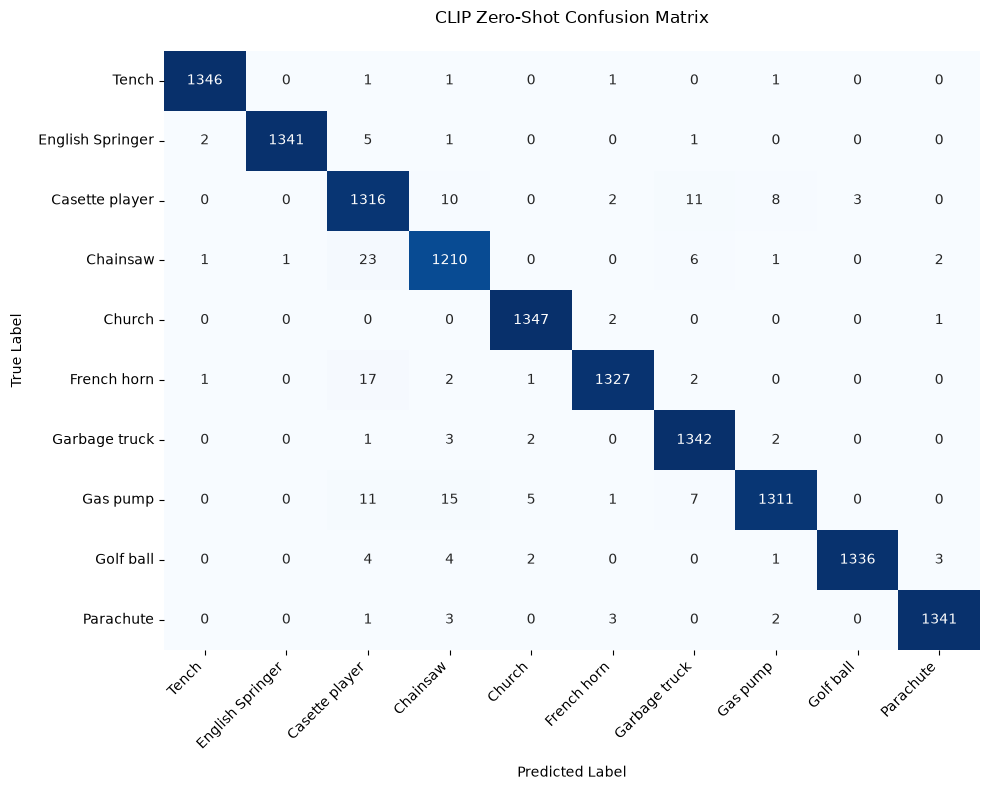

In [18]:
# Confusion Matrix Heatmap
plt.figure(figsize=(10,8))
classes = sorted(df['true_label'].unique())

classnames = ['Tench', 'English Springer', 'Casette player', 'Chainsaw', 'Church',
              'French horn', 'Garbage truck', 'Gas pump', 'Golf ball', 'Parachute']

cm = confusion_matrix(df['true_label'], df['predicted_label'], labels=classes)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classnames,
    yticklabels=classnames,
    cbar=False
)

plt.title('CLIP Zero-Shot Confusion Matrix', pad=20)
plt.ylabel('True Label', labelpad=10)
plt.xlabel('Predicted Label', labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Density Plots

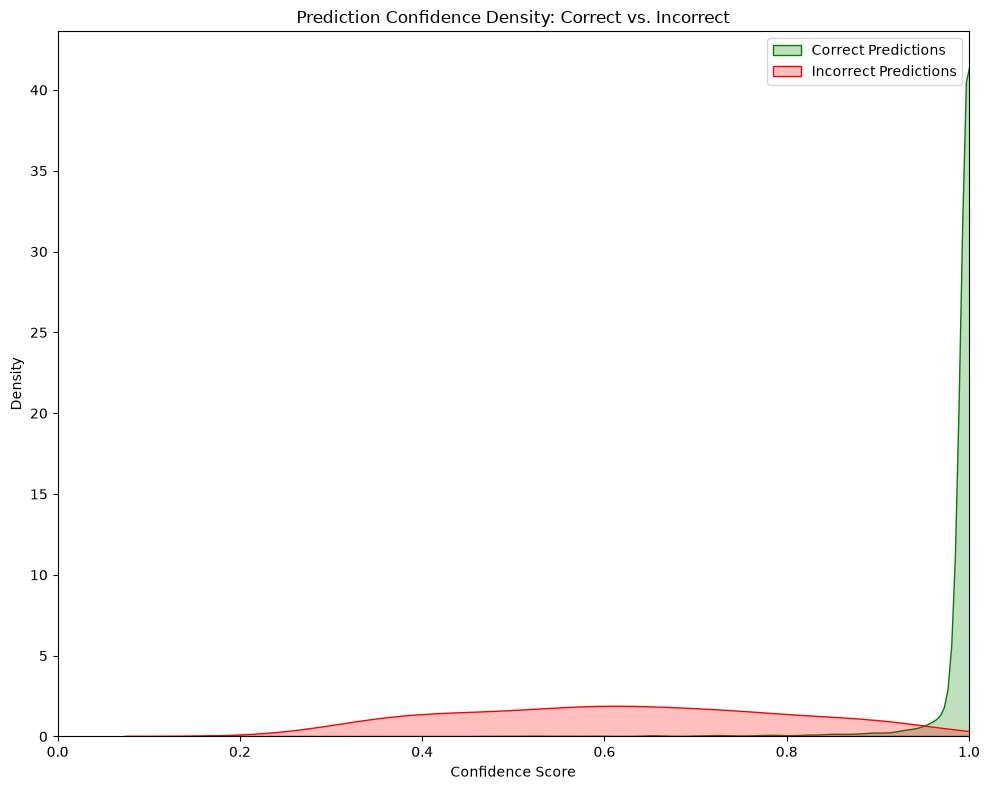

In [24]:
df['is_correct'] = df['true_label'] == df['predicted_label']

plt.figure(figsize=(10,8))
sns.kdeplot(
    data=df[df['is_correct'] == True],
    x='confidence',
    fill=True,
    color='green',
    label='Correct Predictions',
    alpha=0.25,
    warn_singular=False
)

sns.kdeplot(
    data=df[df['is_correct'] == False],
    x='confidence',
    fill=True,
    color='red',
    label='Incorrect Predictions',
    alpha=0.25,
    warn_singular=False
)

plt.title('Prediction Confidence Density: Correct vs. Incorrect')
plt.xlabel('Confidence Score')
plt.ylabel('Density')
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Diagnostics

## Exploring when the model was very wrong

Though it didn't occur very often, the density plot shows that occasionally the model was very confident it had correctly identified an image, but was very wrong. Let's dig deeper into these cases.

In [26]:
very_wrong = df[(df['is_correct'] == False) & (df['confidence'] > 0.95)]

very_wrong

,filename,width,height,train_split,true_label,predicted_label,confidence,is_correct
45,n03425413__ILSVRC2012_val_00017866.jpg,375,500,train,7,2,0.9757,False
5859,n03425413__n03425413_18326.jpg,500,375,train,7,2,0.9940,False


> So, in both cases it predicted 2: Casette player but the image was actually 7: Gas pump! 

Let's view the actual images:

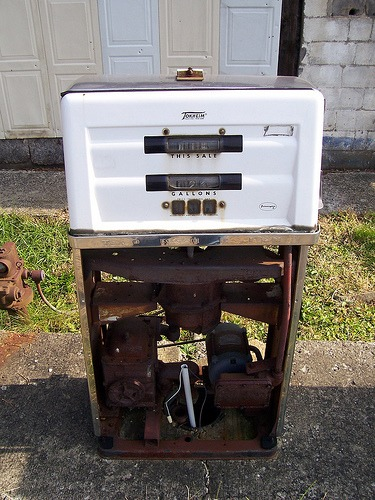

In [36]:
from IPython.display import Image
Image('images/n03425413__ILSVRC2012_val_00017866.jpg', height=200, width=200)

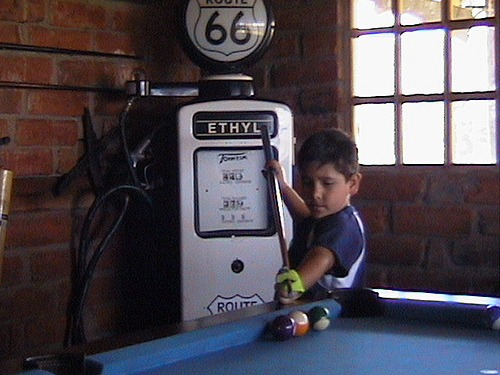

In [35]:
Image('images/n03425413__n03425413_18326.jpg', height=200, width=200)

Ok, these are strange gas pumps, both antique. One is in rough shape, both are unlike typical gas pumps you'd see at a modern station.

How do they compare to they typical casette player?

In [40]:
df[(df['confidence'] == 1) & (df['true_label'] == 2)]

,filename,width,height,train_split,true_label,predicted_label,confidence,is_correct
63,n02979186__n02979186_2226.jpg,300,225,train,2,2,1.0,True
123,n02979186__n02979186_7828.jpg,380,337,train,2,2,1.0,True
162,n02979186__n02979186_13206.jpg,375,500,train,2,2,1.0,True
271,n02979186__n02979186_9339.jpg,500,375,train,2,2,1.0,True
337,n02979186__n02979186_6767.jpg,448,298,train,2,2,1.0,True
...,...,...,...,...,...,...,...,...
12907,n02979186__n02979186_20701.jpg,1992,1819,val,2,2,1.0,True
13102,n02979186__n02979186_11052.jpg,1314,914,val,2,2,1.0,True
13213,n02979186__n02979186_20220.jpg,240,160,val,2,2,1.0,True
13318,n02979186__n02979186_14630.jpg,500,170,val,2,2,1.0,True


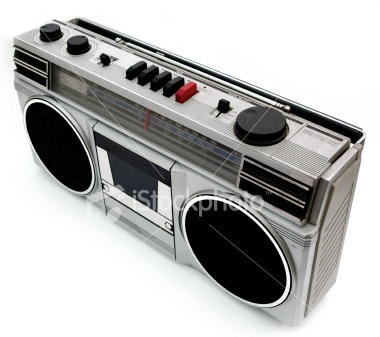

In [46]:
Image('images/n02979186__n02979186_7828.jpg', height=200, width=200)

So, at least some of the stereos share similar color patterns and roughly square shape. Perhaps it's that?

## Mistaken Chainsaws for Gas pumps

In [ ]:
df_3_7 = df[(df['true_label'] == 7) & (df['predicted_label'] == 3)]

In [53]:
df_3_7.describe()

,width,height,true_label,predicted_label,confidence
count,15.000000,15.000000,15.0,15.0,15.000000
mean,419.200000,468.200000,7.0,3.0,0.667907
std,141.383571,90.832813,0.0,0.0,0.207588
min,175.000000,332.000000,7.0,3.0,0.352600
25%,333.000000,375.000000,7.0,3.0,0.477150
50%,375.000000,500.000000,7.0,3.0,0.659000
75%,500.000000,500.000000,7.0,3.0,0.860400
max,800.000000,633.000000,7.0,3.0,0.932100


In [54]:
median_confidence = df_3_7['confidence'].median()
print(f'Median confidence: {median_confidence}')

Median confidence: 0.659


In [57]:
df_3_7.sort_values('confidence', ascending=False).head()

,filename,width,height,train_split,true_label,predicted_label,confidence,is_correct
11257,n03425413__n03425413_20130.jpg,354,500,val,7,3,0.9321,False
4750,n03425413__n03425413_26983.jpg,333,500,train,7,3,0.9194,False
2011,n03425413__n03425413_12714.jpg,399,500,train,7,3,0.9096,False
7284,n03425413__ILSVRC2012_val_00018006.jpg,500,375,train,7,3,0.8861,False
9616,n03425413__n03425413_13922.jpg,333,500,val,7,3,0.8347,False


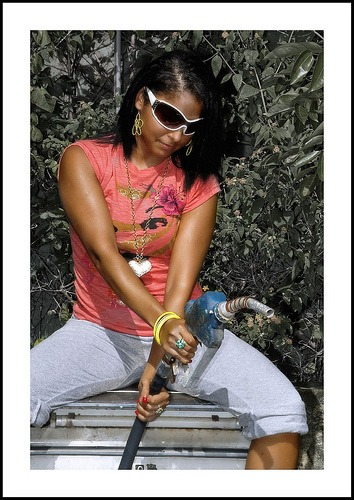

In [58]:
Image('images/n03425413__n03425413_20130.jpg', height=200, width=200)

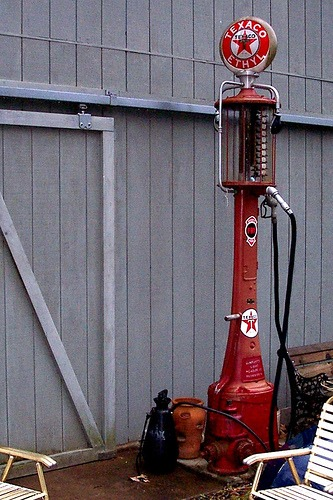

In [59]:
Image('images/n03425413__n03425413_13922.jpg', height=200, width=200)

In [60]:
df_3_7.sort_values('confidence', ascending=False).tail()

,filename,width,height,train_split,true_label,predicted_label,confidence,is_correct
10794,n03425413__n03425413_13620.jpg,375,500,val,7,3,0.4992,False
6943,n03425413__n03425413_3629.jpg,175,500,train,7,3,0.4551,False
9825,n03425413__n03425413_29331.jpg,800,600,val,7,3,0.4429,False
10217,n03425413__n03425413_20742.jpg,500,375,val,7,3,0.4399,False
4094,n03425413__n03425413_20708.jpg,500,332,train,7,3,0.3526,False


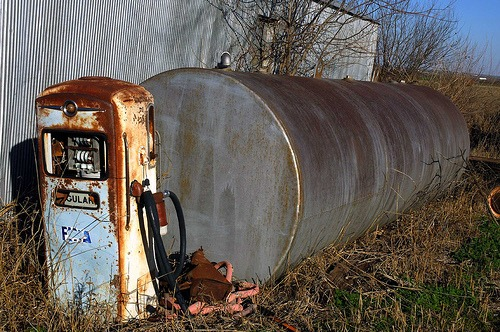

In [61]:
Image('images/n03425413__n03425413_20708.jpg', height=200, width=200)

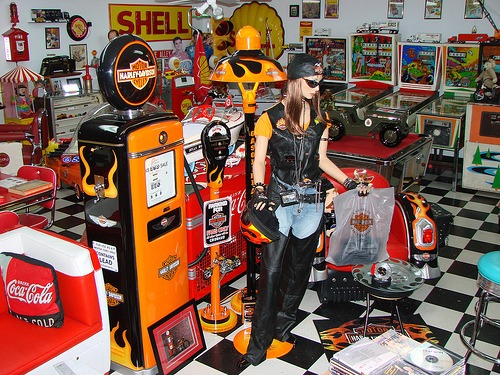

In [62]:
Image('images/n03425413__n03425413_20742.jpg', height=200, width=200)

> Again, these are all strange examples, so its confusion is somewhat understandable.

# Understanding CLIP

This model is lightweight, fast, and efficient. Why?

The graphical illustration from CLIP's GitHub page sums it up nicely:
![CLIP Architecture Graphic](static/CLIP_graphic.png)

Essentially, the model has a two-layered architecture:

1. CLIP was trained on a very large corpus with the sole purpose of describing images. That's the computer vision aspect.
2. The second layer is a text encoder. Based on a dictionary we provided in the program:
    - 'a photo of a casette player'
    - 'a photo of a chainsaw'
    - etc...

Based on this dictionary, the model then matches up the description of the image that the first layer calculated to the most likely match in the dictionary it was provided.

## Why it performs well on imagenette and where it'd fail

The imagenette images fall nicely into distinct classes. A fish is looks very different from a church or a garbage truck. They are hard to mistake.

Also, the classifications are concerned with the type of object in the photo, not what's happening in the photo, or details about the scene. We didn't ask it if it was a dog inside of a church or a fish skydiving with a parachute. In these cases, the model would probably focus mostly on the main subject of the image, because it doesn't have the ability to "think" about what it's seeing.